# Zillow Home Values & Rent - Exploratory Data Analysis

**Data Sources:**
- `zillow_home_values`: 683,279 rows - Zillow Home Value Index (ZHVI) time series
- `zillow_rent`: 30,590 rows - Zillow Observed Rent Index (ZORI) time series

**Objectives:**
1. Understand geographic coverage across NJ zip codes
2. Analyze price trends over time
3. Calculate price-to-rent ratios
4. Identify most/least expensive areas
5. Examine year-over-year and long-term growth rates

In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Connect to database
db_path = Path('../data/db/nj_pipeline.duckdb')
conn = duckdb.connect(str(db_path), read_only=True)
print(f"Connected to: {db_path}")

## 1. Data Overview

In [42]:
# Get schema information
print("=" * 60)
print("ZILLOW HOME VALUES SCHEMA")
print("=" * 60)
conn.execute("""
    DESCRIBE zillow_home_values
""").df()

,column_name,column_type,null,key,default,extra
0,region_id,BIGINT,YES,None,None,None
1,size_rank,BIGINT,YES,None,None,None
2,zip_code,VARCHAR,YES,None,None,None
3,RegionType,VARCHAR,YES,None,None,None
4,StateName,VARCHAR,YES,None,None,None
5,State,VARCHAR,YES,None,None,None
6,city,VARCHAR,YES,None,None,None
7,metro,VARCHAR,YES,None,None,None
8,county,VARCHAR,YES,None,None,None
9,date,TIMESTAMP_NS,YES,None,None,None


In [ ]:
print("=" * 60)
print("ZILLOW RENT SCHEMA")
print("=" * 60)
conn.execute("""
    DESCRIBE zillow_rent
""").df()

In [ ]:
# Sample data
print("\nSample Home Values Data:")
display(conn.execute("""
    SELECT * FROM zillow_home_values
    ORDER BY date DESC
    LIMIT 5
""").df())

print("\nSample Rent Data:")
display(conn.execute("""
    SELECT * FROM zillow_rent
    ORDER BY date DESC
    LIMIT 5
""").df())

## 2. Geographic Coverage

In [43]:
# Coverage by zip code
coverage = conn.execute("""
    SELECT
        COUNT(DISTINCT zhvi.zip_code) as zhvi_zips,
        COUNT(DISTINCT zori.zip_code) as zori_zips,
        COUNT(DISTINCT COALESCE(zhvi.zip_code, zori.zip_code)) as total_zips,
        COUNT(DISTINCT CASE WHEN zhvi.zip_code = zori.zip_code THEN zhvi.zip_code END) as both_sources
    FROM
        (SELECT DISTINCT zip_code FROM zillow_home_values) zhvi
    FULL OUTER JOIN
        (SELECT DISTINCT zip_code FROM zillow_rent) zori
    ON zhvi.zip_code = zori.zip_code
""").df()

print("Geographic Coverage:")
print(f"  Zip codes with ZHVI data: {coverage['zhvi_zips'].iloc[0]}")
print(f"  Zip codes with ZORI data: {coverage['zori_zips'].iloc[0]}")
print(f"  Zip codes with both: {coverage['both_sources'].iloc[0]}")
print(f"  Total unique zip codes: {coverage['total_zips'].iloc[0]}")

Geographic Coverage:
  Zip codes with ZHVI data: 551
  Zip codes with ZORI data: 230
  Zip codes with both: 229
  Total unique zip codes: 552


In [44]:
# Date range coverage
date_ranges = conn.execute("""
    SELECT
        'ZHVI' as source,
        MIN(date) as earliest_date,
        MAX(date) as latest_date,
        COUNT(DISTINCT date) as unique_months,
        COUNT(*) as total_records
    FROM zillow_home_values
    UNION ALL
    SELECT
        'ZORI' as source,
        MIN(date) as earliest_date,
        MAX(date) as latest_date,
        COUNT(DISTINCT date) as unique_months,
        COUNT(*) as total_records
    FROM zillow_rent
""").df()

print("\nTemporal Coverage:")
display(date_ranges)

,source,earliest_date,latest_date,unique_months,total_records
0,ZHVI,2000-01-31,2026-01-31,313,683279
1,ZORI,2015-01-31,2026-01-31,133,30590


## 3. Latest Market Snapshot

In [45]:
# Latest values by zip code
latest_snapshot = conn.execute("""
    WITH latest_zhvi AS (
        SELECT
            zip_code,
            city,
            county,
            zhvi_usd as zhvi_latest,
            date as zhvi_date,
            ROW_NUMBER() OVER (PARTITION BY zip_code ORDER BY date DESC) as rn
        FROM zillow_home_values
    ),
    latest_zori AS (
        SELECT
            zip_code,
            zori_usd as zori_latest,
            date as zori_date,
            ROW_NUMBER() OVER (PARTITION BY zip_code ORDER BY date DESC) as rn
        FROM zillow_rent
    )
    SELECT
        COALESCE(z.zip_code, r.zip_code) as zip_code,
        z.city,
        z.county,
        z.zhvi_latest,
        r.zori_latest,
        ROUND(z.zhvi_latest / (r.zori_latest * 12), 2) as price_to_rent_ratio,
        z.zhvi_date,
        r.zori_date
    FROM latest_zhvi z
    FULL OUTER JOIN latest_zori r ON z.zip_code = r.zip_code AND r.rn = 1
    WHERE z.rn = 1
    ORDER BY z.zhvi_latest DESC NULLS LAST
""").df()

print(f"\nLatest Market Data: {len(latest_snapshot)} zip codes")
print("\nTop 20 Most Expensive Zip Codes (by ZHVI):")
display(latest_snapshot.head(20))

,zip_code,city,county,zhvi_latest,zori_latest,price_to_rent_ratio,zhvi_date,zori_date
0,08202,Avalon,Cape May County,4.694849e+06,NaN,NaN,2026-01-31,NaT
1,08247,Stone Harbor,Cape May County,4.594892e+06,NaN,NaN,2026-01-31,NaT
2,08750,Sea Girt,Monmouth County,4.402595e+06,NaN,NaN,2026-01-31,NaT
3,08738,Mantoloking,Ocean County,4.262706e+06,NaN,NaN,2026-01-31,NaT
4,08403,Longport,Atlantic County,3.102561e+06,NaN,NaN,2026-01-31,NaT
5,08248,Strathmere,Cape May County,2.347031e+06,NaN,NaN,2026-01-31,NaT
6,08739,Lavallette,Ocean County,2.278011e+06,NaN,NaN,2026-01-31,NaT
7,07078,Short Hills,Essex County,2.258922e+06,5617.500000,33.51,2026-01-31,2026-01-31
8,07723,Deal,Monmouth County,2.049092e+06,NaN,NaN,2026-01-31,NaT
9,08243,Sea Isle City,Cape May County,1.999521e+06,NaN,NaN,2026-01-31,NaT


In [46]:
# Summary statistics
print("\nMarket Summary Statistics:")
print("\nHome Values (ZHVI):")
print(latest_snapshot['zhvi_latest'].describe())

print("\nRent Values (ZORI):")
print(latest_snapshot['zori_latest'].describe())

print("\nPrice-to-Rent Ratio:")
print(latest_snapshot['price_to_rent_ratio'].describe())


Market Summary Statistics:

Home Values (ZHVI):
count    5.510000e+02
mean     6.412177e+05
std      4.663429e+05
min      1.649615e+05
25%      4.128464e+05
50%      5.383777e+05
75%      7.174321e+05
max      4.694849e+06
Name: zhvi_latest, dtype: float64

Rent Values (ZORI):
count      228.000000
mean      2763.041457
std       1776.769988
min       1550.000000
25%       2199.583333
50%       2496.372222
75%       2850.098328
max      26250.000000
Name: zori_latest, dtype: float64

Price-to-Rent Ratio:
count    228.000000
mean      18.293509
std        6.701208
min        6.100000
25%       14.282500
50%       17.050000
75%       21.477500
max       44.860000
Name: price_to_rent_ratio, dtype: float64


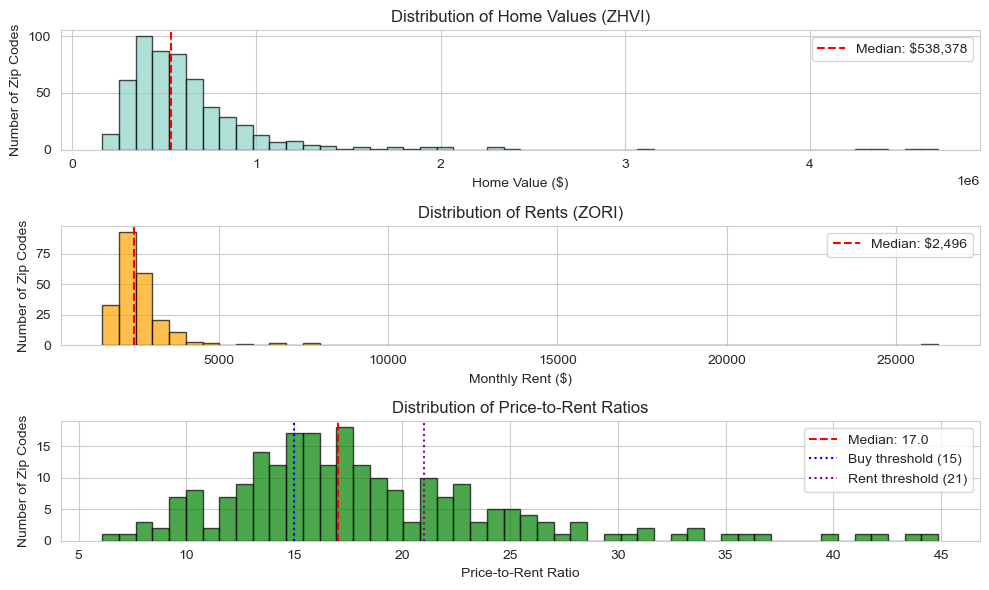

In [50]:
# Distribution plots
fig, axes = plt.subplots(3, 1, figsize=(10, 6))

# ZHVI distribution
axes[0].hist(latest_snapshot['zhvi_latest'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Home Value ($)')
axes[0].set_ylabel('Number of Zip Codes')
axes[0].set_title('Distribution of Home Values (ZHVI)')
axes[0].axvline(latest_snapshot['zhvi_latest'].median(), color='red', linestyle='--', label=f'Median: ${latest_snapshot["zhvi_latest"].median():,.0f}')
axes[0].legend()

# ZORI distribution
axes[1].hist(latest_snapshot['zori_latest'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Monthly Rent ($)')
axes[1].set_ylabel('Number of Zip Codes')
axes[1].set_title('Distribution of Rents (ZORI)')
axes[1].axvline(latest_snapshot['zori_latest'].median(), color='red', linestyle='--', label=f'Median: ${latest_snapshot["zori_latest"].median():,.0f}')
axes[1].legend()

# Price-to-Rent Ratio distribution
axes[2].hist(latest_snapshot['price_to_rent_ratio'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].set_xlabel('Price-to-Rent Ratio')
axes[2].set_ylabel('Number of Zip Codes')
axes[2].set_title('Distribution of Price-to-Rent Ratios')
axes[2].axvline(latest_snapshot['price_to_rent_ratio'].median(), color='red', linestyle='--', label=f'Median: {latest_snapshot["price_to_rent_ratio"].median():.1f}')
axes[2].axvline(15, color='blue', linestyle=':', label='Buy threshold (15)')
axes[2].axvline(21, color='purple', linestyle=':', label='Rent threshold (21)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 4. County-Level Analysis

In [51]:
# County summaries
county_summary = conn.execute("""
                              WITH latest_zhvi AS (SELECT zip_code,
                                                          county,
                                                          zhvi_usd,
                                                          ROW_NUMBER() OVER (PARTITION BY zip_code ORDER BY date DESC) as rn
                                                   FROM zillow_home_values)
                              SELECT county,
                                     COUNT(DISTINCT zip_code)   as num_zips,
                                     ROUND(AVG(zhvi_usd), 0)    as avg_home_value,
                                     ROUND(MEDIAN(zhvi_usd), 0) as median_home_value,
                                     ROUND(MIN(zhvi_usd), 0)    as min_home_value,
                                     ROUND(MAX(zhvi_usd), 0)    as max_home_value
                              FROM latest_zhvi
                              WHERE rn = 1
                                AND county IS NOT NULL
                              GROUP BY county
                              ORDER BY median_home_value DESC
                              """).df()

print("Home Values by County:")
display(county_summary)


,county,num_zips,avg_home_value,median_home_value,min_home_value,max_home_value
0,Cape May County,14,1637215.0,1134554.0,491427.0,4694849.0
1,Somerset County,21,904332.0,937400.0,500744.0,1400189.0
2,Monmouth County,49,1079723.0,887818.0,402285.0,4402595.0
3,Hunterdon County,19,775653.0,790764.0,456804.0,1044896.0
4,Ocean County,30,1015994.0,723502.0,432014.0,4262706.0
5,Bergen County,65,858150.0,718748.0,460744.0,2955123.0
6,Morris County,46,729914.0,691975.0,469428.0,1951408.0
7,Middlesex County,36,703445.0,661005.0,410069.0,1153320.0
8,Essex County,31,758760.0,640658.0,395007.0,2250487.0
9,Mercer County,19,722738.0,609650.0,247608.0,1596991.0


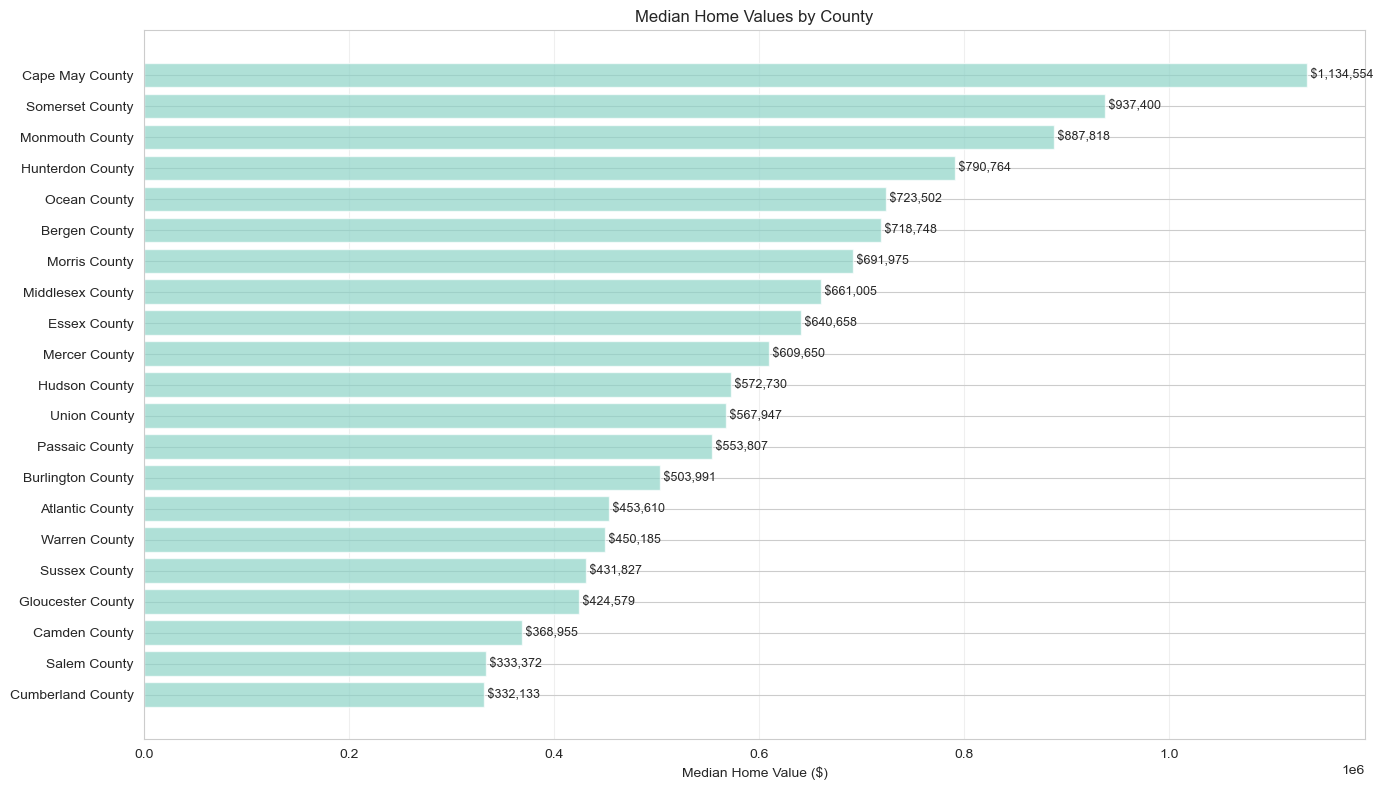

In [52]:
# County comparison plot
fig, ax = plt.subplots(figsize=(14, 8))
county_summary_sorted = county_summary.sort_values('median_home_value')
ax.barh(county_summary_sorted['county'], county_summary_sorted['median_home_value'], alpha=0.7)
ax.set_xlabel('Median Home Value ($)')
ax.set_title('Median Home Values by County')
ax.grid(axis='x', alpha=0.3)
for i, (county, value) in enumerate(zip(county_summary_sorted['county'], county_summary_sorted['median_home_value'])):
    ax.text(value, i, f' ${value:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Time Series Trends

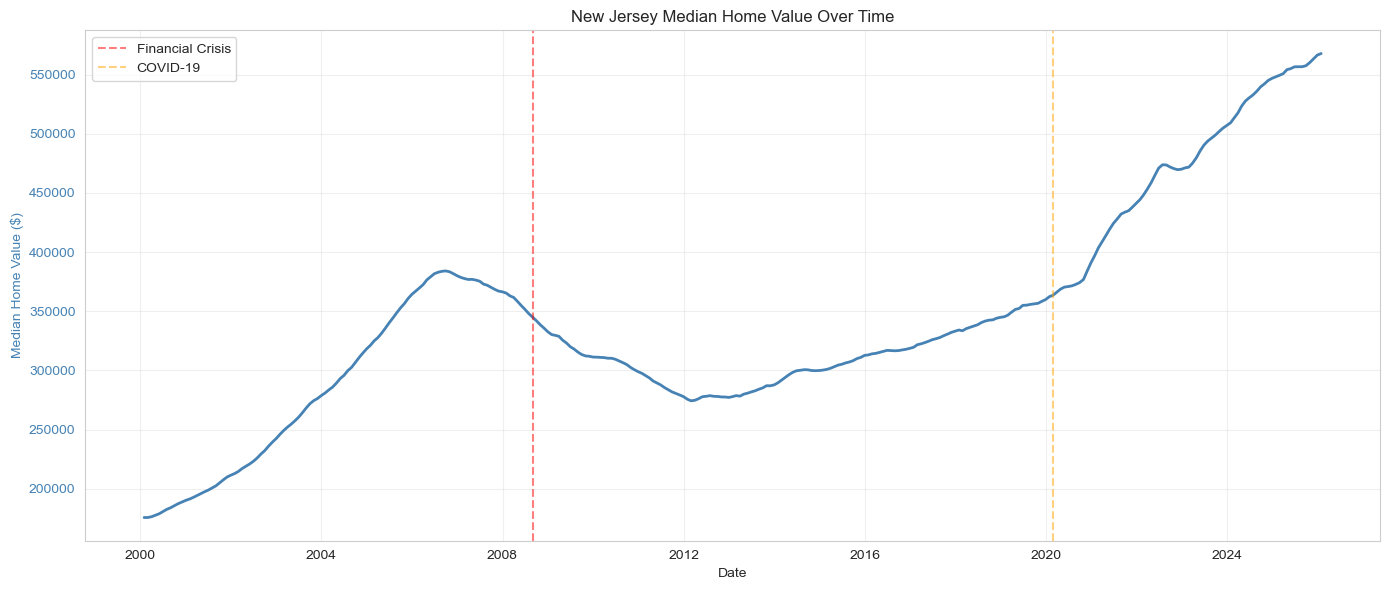

In [54]:
# NJ-wide median trends
nj_trends = conn.execute("""
    SELECT
        date,
        MEDIAN(zhvi_usd) as median_zhvi,
        COUNT(DISTINCT zip_code) as num_zips
    FROM zillow_home_values
    GROUP BY date
    ORDER BY date
""").df()

nj_trends['date'] = pd.to_datetime(nj_trends['date'])



print(f"\nMedian home value change:")
print(f"  First available ({nj_trends['date'].min().date()}): ${nj_trends['median_zhvi'].iloc[0]:,.0f}")
print(f"  Most recent ({nj_trends['date'].max().date()}): ${nj_trends['median_zhvi'].iloc[-1]:,.0f}")
print(f"  Total change: ${nj_trends['median_zhvi'].iloc[-1] - nj_trends['median_zhvi'].iloc[0]:,.0f} ({(nj_trends['median_zhvi'].iloc[-1] / nj_trends['median_zhvi'].iloc[0] - 1) * 100:.1f}%)")


fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(nj_trends['date'], nj_trends['median_zhvi'], linewidth=2, color='steelblue')
ax1.set_xlabel('Date')
ax1.set_ylabel('Median Home Value ($)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_title('New Jersey Median Home Value Over Time')
ax1.grid(True, alpha=0.3)

# Mark major events
ax1.axvline(pd.Timestamp('2008-09-01'), color='red', linestyle='--', alpha=0.5, label='Financial Crisis')
ax1.axvline(pd.Timestamp('2020-03-01'), color='orange', linestyle='--', alpha=0.5, label='COVID-19')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

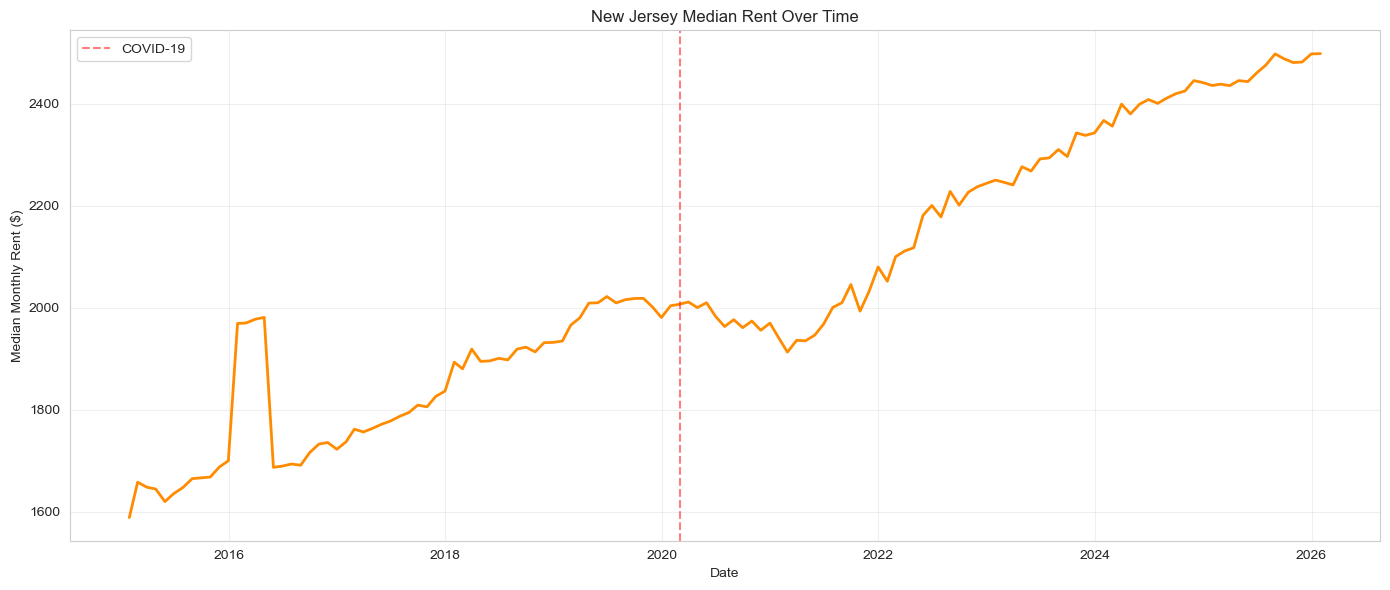

In [56]:
if len(rent_trends) > 0:
    print(f"\nMedian rent change:")
    print(f"  First available ({rent_trends['date'].min().date()}): ${rent_trends['median_zori'].iloc[0]:,.0f}")
    print(f"  Most recent ({rent_trends['date'].max().date()}): ${rent_trends['median_zori'].iloc[-1]:,.0f}")
    print(f"  Total change: ${rent_trends['median_zori'].iloc[-1] - rent_trends['median_zori'].iloc[0]:,.0f} ({(rent_trends['median_zori'].iloc[-1] / rent_trends['median_zori'].iloc[0] - 1) * 100:.1f}%)")

# Rent trends
rent_trends = conn.execute("""
    SELECT
        date,
        MEDIAN(zori_usd) as median_zori,
        COUNT(DISTINCT zip_code) as num_zips
    FROM zillow_rent
    GROUP BY date
    ORDER BY date
""").df()

rent_trends['date'] = pd.to_datetime(rent_trends['date'])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(rent_trends['date'], rent_trends['median_zori'], linewidth=2, color='darkorange')
ax.set_xlabel('Date')
ax.set_ylabel('Median Monthly Rent ($)')
ax.set_title('New Jersey Median Rent Over Time')
ax.grid(True, alpha=0.3)
ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5, label='COVID-19')
ax.legend()

plt.tight_layout()
plt.show()



## 6. Growth Rate Analysis

In [57]:
def calculate_growth_rates(data, value_column, date_column='year'):
    """
    Calculate Year-over-Year and 5-year growth rates.

    Parameters:
    - data: DataFrame containing the time series data
    - value_column: Column name for values to calculate growth on
    - date_column: Column name for the date/year (default: 'year')

    Returns:
    - DataFrame with original data plus 'yoy_growth' and 'five_year_growth' columns
    """
    result = data.copy()
    result['yoy_growth'] = result[value_column].pct_change(periods=1) * 100
    result['five_year_growth'] = result[value_column].pct_change(periods=5) * 100
    return result

growth_rates = conn.execute("""
    WITH latest AS (
        SELECT zip_code, city, county, zhvi_usd as current_value, date as current_date
        FROM zillow_home_values
        QUALIFY ROW_NUMBER() OVER (PARTITION BY zip_code ORDER BY date DESC) = 1
    ),
    one_year_ago AS (
        SELECT zip_code, zhvi_usd as value_1y_ago
        FROM zillow_home_values
        WHERE date = (SELECT MAX(date) - INTERVAL 12 MONTH FROM zillow_home_values)
    ),
    five_years_ago AS (
        SELECT zip_code, zhvi_usd as value_5y_ago
        FROM zillow_home_values
        WHERE date = (SELECT MAX(date) - INTERVAL 60 MONTH FROM zillow_home_values)
    )
    SELECT
        l.zip_code, l.city, l.county, l.current_value,
        y.value_1y_ago, f.value_5y_ago,
        ROUND((l.current_value - y.value_1y_ago) / y.value_1y_ago * 100, 2) as yoy_pct_change,
        ROUND((l.current_value - f.value_5y_ago) / f.value_5y_ago * 100, 2) as five_year_pct_change
    FROM latest l
    LEFT JOIN one_year_ago y ON l.zip_code = y.zip_code
    LEFT JOIN five_years_ago f ON l.zip_code = f.zip_code
    WHERE y.value_1y_ago IS NOT NULL
    ORDER BY yoy_pct_change DESC
""").df()

print("\nTop 15 Fastest Growing Zip Codes (YoY):")
display(growth_rates.head(15))

print("\nBottom 15 Zip Codes (YoY):")
display(growth_rates.tail(15))

,zip_code,city,county,current_value,value_1y_ago,value_5y_ago,yoy_pct_change,five_year_pct_change
8676,07024,Fort Lee,Bergen County,2.924603e+05,9.942105e+05,2.453283e+05,-70.58,19.21
8677,07024,Fort Lee,Bergen County,2.924603e+05,9.942105e+05,6.876121e+05,-70.58,-57.47
8678,07024,Fort Lee,Bergen County,2.924603e+05,9.942105e+05,4.433050e+05,-70.58,-34.03
8679,07723,Deal,Monmouth County,2.049092e+06,7.147102e+06,2.169703e+06,-71.33,-5.56
8680,07723,Deal,Monmouth County,2.049092e+06,7.147102e+06,4.710972e+06,-71.33,-56.50
8681,07723,Deal,Monmouth County,2.049092e+06,7.147102e+06,1.083326e+06,-71.33,89.15
8682,07723,Deal,Monmouth County,2.049092e+06,7.147102e+06,2.309286e+06,-71.33,-11.27
8683,07750,Monmouth Beach,Monmouth County,5.804567e+05,2.053260e+06,3.876092e+05,-71.73,49.75
8684,07750,Monmouth Beach,Monmouth County,5.804567e+05,2.053260e+06,1.054584e+06,-71.73,-44.96
8685,07750,Monmouth Beach,Monmouth County,5.804567e+05,2.053260e+06,7.056811e+05,-71.73,-17.75


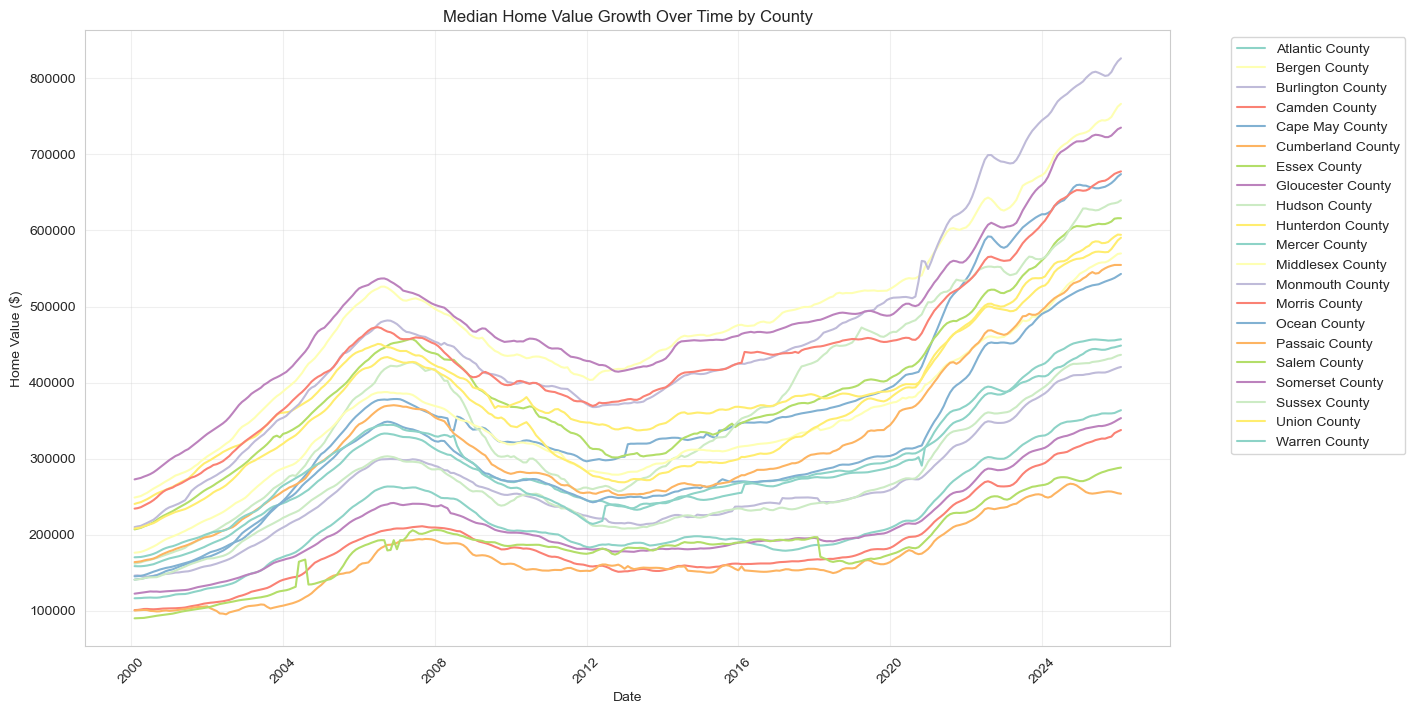

In [67]:
# lineplot of home value by county over time

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_title('Median Home Value Growth Over Time by County')
ax.set_xlabel('Date')
ax.set_ylabel('Home Value ($)')
ax.grid(True, alpha=0.3)

county_median_zhvi = conn.execute("""
    SELECT
        date,
        county,
        MEDIAN(zhvi_usd) as median_zhvi
    FROM zillow_home_values
    GROUP BY date, county
    ORDER BY date, county
""").df()
county_median_zhvi['date'] = pd.to_datetime(county_median_zhvi['date'])

for county in county_median_zhvi['county'].unique():
    county_data = county_median_zhvi[county_median_zhvi['county'] == county]
    ax.plot(county_data['date'], county_data['median_zhvi'], label=county)

ax.ticklabel_format(style='plain', axis='y') # Disable scientific notation for y-axis
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



## 7. Affordability Analysis

In [62]:
# Price-to-rent ratio analysis
ptr_analysis = latest_snapshot[['zip_code', 'city', 'county', 'zhvi_latest', 'zori_latest', 'price_to_rent_ratio']].dropna()

print("\nPrice-to-Rent Ratio Categories:")
print(f"  Strongly favor buying (< 15): {len(ptr_analysis[ptr_analysis['price_to_rent_ratio'] < 15])} zips")
print(f"  Neutral (15-21): {len(ptr_analysis[(ptr_analysis['price_to_rent_ratio'] >= 15) & (ptr_analysis['price_to_rent_ratio'] <= 21)])} zips")
print(f"  Favor renting (> 21): {len(ptr_analysis[ptr_analysis['price_to_rent_ratio'] > 21])} zips")

print("\nMost Favorable for Buying (lowest price-to-rent):")
display(ptr_analysis.nsmallest(10, 'price_to_rent_ratio'))

print("\nMost Favorable for Renting (highest price-to-rent):")
display(ptr_analysis.nlargest(10, 'price_to_rent_ratio'))

,zip_code,city,county,zhvi_latest,zori_latest,price_to_rent_ratio
30,08057,Moorestown Township,Burlington County,1.186085e+06,2203.333333,44.86
12,08735,Lavallette,Ocean County,1.842794e+06,3500.000000,43.88
16,08540,Princeton,Mercer County,1.596991e+06,3154.309764,42.19
46,08536,Plainsboro,Middlesex County,1.042400e+06,2096.939815,41.43
70,08260,Wildwood,Cape May County,9.135100e+05,1900.000000,40.07
42,08701,Lakewood,Ocean County,1.045928e+06,2385.000000,36.55
17,08736,Manasquan,Monmouth County,1.589933e+06,3708.333333,35.73
18,08742,Point Pleasant,Ocean County,1.433887e+06,3399.444444,35.15
7,07078,Short Hills,Essex County,2.258922e+06,5617.500000,33.51
38,08751,Seaside Heights,Ocean County,1.126696e+06,2811.111111,33.40


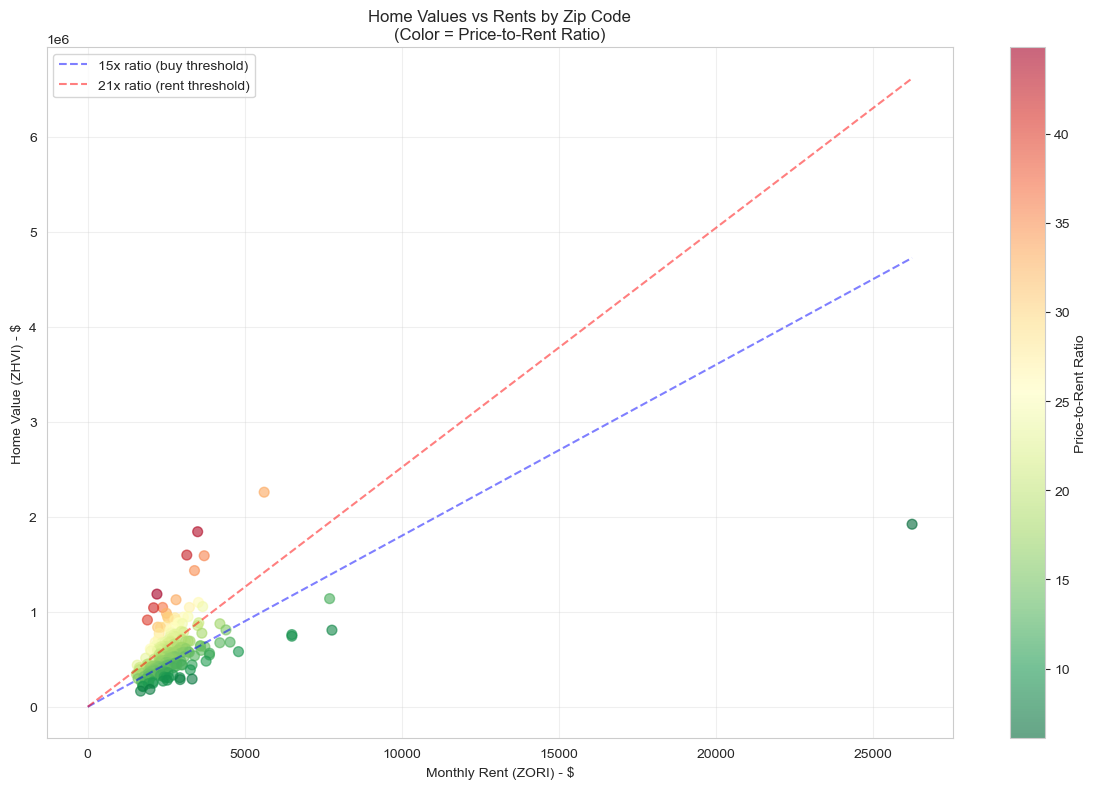

In [63]:
# Scatter plot: Home Value vs Rent
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(ptr_analysis['zori_latest'], ptr_analysis['zhvi_latest'],
                     c=ptr_analysis['price_to_rent_ratio'], cmap='RdYlGn_r',
                     alpha=0.6, s=50)
ax.set_xlabel('Monthly Rent (ZORI) - $')
ax.set_ylabel('Home Value (ZHVI) - $')
ax.set_title('Home Values vs Rents by Zip Code\n(Color = Price-to-Rent Ratio)')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Price-to-Rent Ratio')

# Add reference lines for typical ratios
max_rent = ptr_analysis['zori_latest'].max()
ax.plot([0, max_rent], [0, max_rent * 12 * 15], 'b--', alpha=0.5, label='15x ratio (buy threshold)')
ax.plot([0, max_rent], [0, max_rent * 12 * 21], 'r--', alpha=0.5, label='21x ratio (rent threshold)')
ax.legend()

plt.tight_layout()
plt.show()

## 8. Key Findings Summary

In [41]:
print("="*70)
print("KEY FINDINGS - ZILLOW DATA")
print("="*70)

print(f"\n1. COVERAGE")
print(f"   • {coverage['zhvi_zips'].iloc[0]} zip codes with home value data")
print(f"   • {coverage['zori_zips'].iloc[0]} zip codes with rent data")
print(f"   • Data spans from {nj_trends['date'].min().date()} to {nj_trends['date'].max().date()}")

print(f"\n2. CURRENT MARKET (Latest Month)")
print(f"   • Median home value: ${latest_snapshot['zhvi_latest'].median():,.0f}")
print(f"   • Median monthly rent: ${latest_snapshot['zori_latest'].median():,.0f}")
print(f"   • Median price-to-rent ratio: {latest_snapshot['price_to_rent_ratio'].median():.1f}")

print(f"\n3. MOST EXPENSIVE AREAS")
top_3_expensive = latest_snapshot.nlargest(3, 'zhvi_latest')
for idx, row in top_3_expensive.iterrows():
    print(f"   • {row['zip_code']} ({row['city']}): ${row['zhvi_latest']:,.0f}")

print(f"\n4. GROWTH TRENDS")
print(f"   • Median YoY growth: {growth_rates['yoy_pct_change'].median():.1f}%")
print(f"   • Median 5-year growth: {growth_rates['five_year_pct_change'].median():.1f}%")
print(f"   • Fastest growing zip (YoY): {growth_rates.iloc[0]['zip_code']} ({growth_rates.iloc[0]['city']}) at {growth_rates.iloc[0]['yoy_pct_change']:.1f}%")

print(f"\n5. AFFORDABILITY")
buy_favorable = len(ptr_analysis[ptr_analysis['price_to_rent_ratio'] < 15])
rent_favorable = len(ptr_analysis[ptr_analysis['price_to_rent_ratio'] > 21])
print(f"   • {buy_favorable} zip codes favor buying (ratio < 15)")
print(f"   • {rent_favorable} zip codes favor renting (ratio > 21)")

print("\n" + "="*70)

KEY FINDINGS - ZILLOW DATA

1. COVERAGE
   • 551 zip codes with home value data
   • 230 zip codes with rent data
   • Data spans from 2000-01-31 to 2026-01-31

2. CURRENT MARKET (Latest Month)
   • Median home value: $657,744
   • Median monthly rent: $2,496
   • Median price-to-rent ratio: 22.5

3. MOST EXPENSIVE AREAS
   • 07723 (Deal): $8,169,608
   • 07620 (Alpine): $5,085,363
   • 08202 (Avalon): $4,694,849

4. GROWTH TRENDS
   • Median YoY growth: 9.4%
   • Median 5-year growth: 58.0%
   • Fastest growing zip (YoY): 08403 (Longport) at 517.2%

5. AFFORDABILITY
   • 19 zip codes favor buying (ratio < 15)
   • 142 zip codes favor renting (ratio > 21)



In [ ]:
conn.close()
print("\nAnalysis complete. Database connection closed.")